(example_isi_multiclass_classification_example)=

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from uniharmony import verbosity
from uniharmony.datasets import make_multisite_classification
from uniharmony.interpolation import IntraSiteInterpolation


sns.set_theme(style="whitegrid")
verbosity("warning")

2026-04-30 09:31:47 [warning  ] signal_strength is 0. Adding a delta (1e-6) to signal_strength to avoid degenerate data.


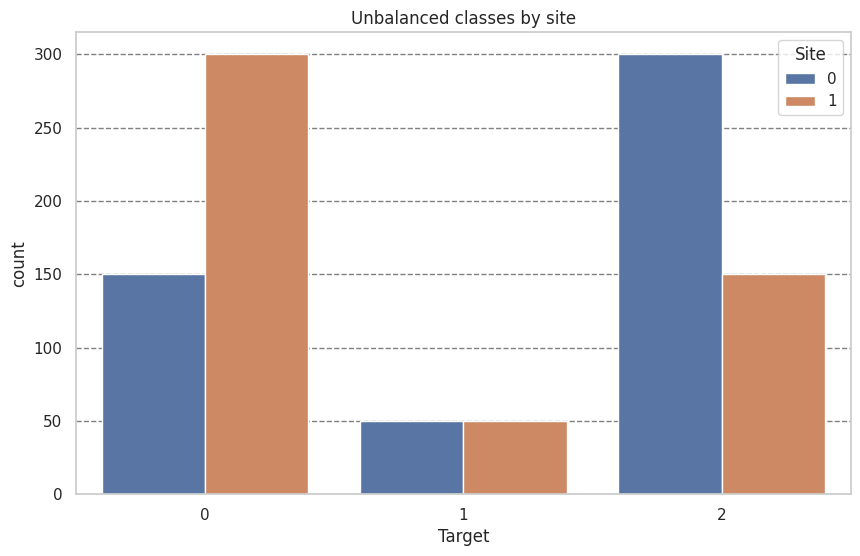

In [2]:
X, y, sites = make_multisite_classification(
    n_classes=3,
    n_samples=1000,
    n_sites=2,
    n_features=2,
    # one value per class, one list per site.
    balance_per_site=[[0.3, 0.1, 0.6], [0.6, 0.1, 0.3]],
    signal_strength=0,
    random_state=23,
)
df = pd.DataFrame({"Target": y, "Site": sites})
plt.figure(figsize=[10, 6])
plt.title("Unbalanced classes by site")
sns.countplot(df, x="Target", hue="Site")
plt.grid(axis="y", color="black", alpha=0.5, linestyle="--")

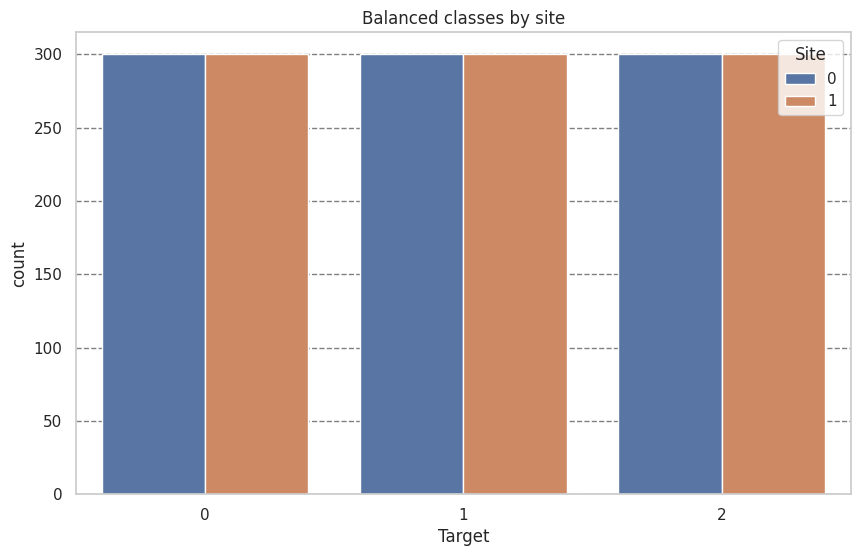

In [3]:
isi = IntraSiteInterpolation()
X_r, y_r = isi.fit_resample(X, y, sites=sites)
df = pd.DataFrame(
    {
        "Target": y_r,
        "Site": isi.sites_resampled_,
        "Feature 1": X_r[:, 0],
        "Feature 2": X_r[:, 1],
    }
)
plt.figure(figsize=[10, 6])
plt.title("Balanced classes by site")
sns.countplot(df, x="Target", hue="Site")
plt.grid(axis="y", color="black", alpha=0.5, linestyle="--")